# Preparación

Librerías

In [ ]:
# 1. Habilitar widgets en Colab
#from google.colab import output
#output.enable_custom_widget_manager()

# 2. Activar el backend interactivo ANTES de importar matplotlib
#%matplotlib widget

import numpy as np #librería para matrices y vectores
import math #librería de operaciones matemáticas
import matplotlib.pyplot as plt #librería para graficar en 3D

import time
from IPython.display import display, clear_output
#from IPython.display import HTML
#from matplotlib.animation import FuncAnimation


#Se debe instalar primero pytransform3d
!pip install pytransform3d
from pytransform3d.transformations import plot_transform
from pytransform3d.plot_utils import make_3d_axis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 6.8 MB/s eta 0:00:00


Función para crear matrices de transformación

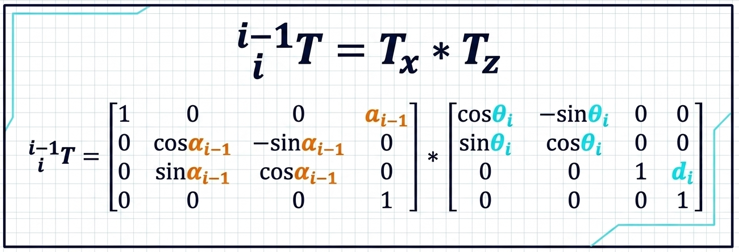

In [ ]:
def fkine(DH):
  DH = np.array(DH)  # Convert DH to a NumPy array
  dofs = DH.shape[0]
  #print(f"Degrees of freedom (dofs): {dofs}\n")
  T = np.eye(4) # Initialize T as a 4x4 identity matrix
  for d in range(dofs): # Iterate through all rows of the DH table

    # Create Tx matrix (Rotation around X and Translation along X)
    Tx_mat = np.array([[1, 0,                 0,                  DH[d,1]],
                       [0, math.cos(DH[d,0]), -math.sin(DH[d,0]), 0],
                       [0, math.sin(DH[d,0]), math.cos(DH[d,0]),  0],
                       [0, 0,                 0,                  1]])

    # Create Ty matrix (Rotation around Z and Translation along Z)
    Tz_mat = np.array([[math.cos(DH[d,2]), -math.sin(DH[d,2]), 0, 0],
                       [math.sin(DH[d,2]), math.cos(DH[d,2]),  0, 0], # Corrected DH[d,0] to DH[d,2]
                       [0,                 0,                  1, DH[d,3]],
                       [0,                 0,                  0, 1]])

    T = np.dot(T, np.dot(Tx_mat, Tz_mat)) # Use np.dot for matrix multiplication

  return T

Función para graficar sistemas de coordenadas

In [ ]:
def plot_frame(ax, T, colorframe, size, name):
    # Extraer el origen y la matriz de rotación de la matriz 4x4
    origin = T[:3, 3]
    R = T[:3, :3]

    # Graficar los 3 ejes X, Y, Z con el mismo color
    for i in range(3):
        axis = R[:, i] * size
        ax.quiver(origin[0], origin[1], origin[2],
                  axis[0], axis[1], axis[2],
                  color=colorframe, arrow_length_ratio=0.1)

    x_tip = origin + R[:, 0] * size
    y_tip = origin + R[:, 1] * size
    z_tip = origin + R[:, 2] * size


    # Agregar la etiqueta en el origen
    ax.text(x_tip[0], x_tip[1], x_tip[2], f' {'x'}', color=colorframe)
    ax.text(y_tip[0], y_tip[1], y_tip[2], f' {'y'}', color=colorframe)
    ax.text(z_tip[0], z_tip[1], z_tip[2], f' {'z'}', color=colorframe)
    ax.text(origin[0], origin[1], origin[2], f' {name}', color=colorframe)

# Simulación del Brazo Robótico

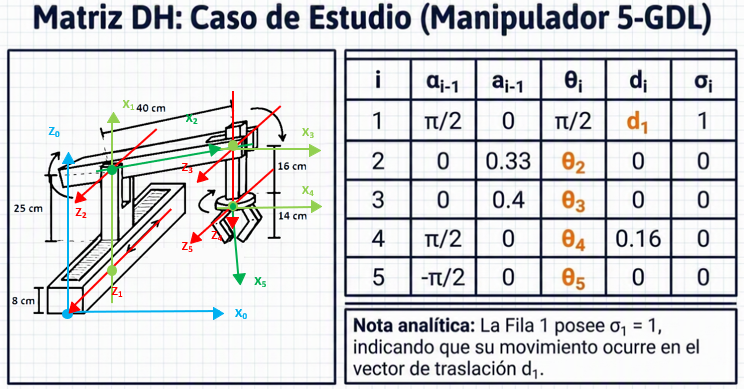

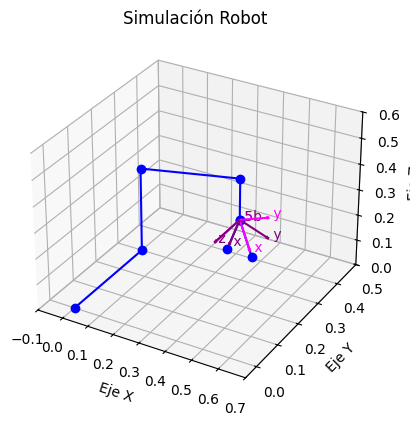

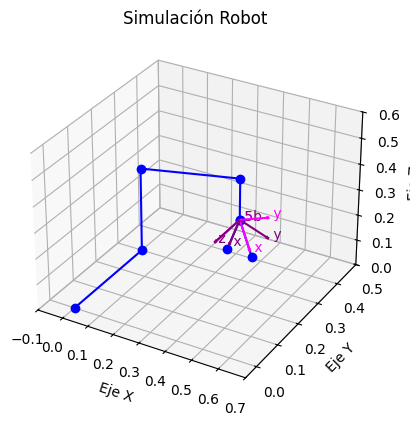

In [ ]:
# Variables

d1i = 0
d1f = -0.3
t2i = math.radians(-90)
t2f = math.radians(-80)
t3i = math.radians(0)
t3f = math.radians(-10)
t4i = math.radians(90)
t4f = math.radians(0)
t5i = math.radians(0)
t5f = math.radians(-70)

# Inicializar gráfica
#Configurar el lienzo en 3D
fig = plt.figure()

# El parámetro projection='3d' es el que habilita el entorno tridimensional
ax = fig.add_subplot(111, projection='3d')

t2 = t2i
t3 = t3i
t4 = t4i
t5 = t5i


for d1 in np.linspace(d1i, d1f, 20):

  clear_output(wait=True)
  ax.clear()


  # Matriz de parámetros Denavit-Hartenber

  DH = np.array([[math.pi/2, 0,    math.pi/2, d1],
                [0,          0.33, t2,        0],
                [0,          0.4,  t3,        0],
                [math.pi/2,  0,    t4,        0.16],
                [-math.pi/2, 0,    t5,        0]])

  t6 = math.radians(180) - t5

  DH2 = np.array([[math.pi/2, 0,    math.pi/2, d1],
                [0,          0.33, t2,        0],
                [0,          0.4,  t3,        0],
                [math.pi/2,  0,    t4,        0.16],
                [-math.pi/2, 0,    t6,        0]])


  # Calcular matrices de transformación

  T50 = fkine(DH)
  T50b = fkine(DH2)
  T40 = fkine(DH[0:4,:])
  T30 = fkine(DH[0:3,:])
  T20 = fkine(DH[0:2,:])
  T10 = fkine(DH[0:1,:])


  # Articulaciones y efector final

  OR = np.array([0,0,0]).reshape(-1, 1)
  P10 = T10[0:3,3].reshape(-1, 1)
  P20 = T20[0:3,3].reshape(-1, 1)
  P30 = T30[0:3,3].reshape(-1, 1)
  P40 = T40[0:3,3].reshape(-1, 1)

  EF5 = np.array([0.14,0,0,1]).reshape(-1, 1)
  EF0 = np.dot(T50, EF5)
  EF0 = EF0[:-1]
  EF0b = np.dot(T50b, EF5)
  EF0b = EF0b[:-1]

  Rob = np.hstack((OR,P10,P20,P30,P40,EF0))
  Rob_b = np.hstack((P40,EF0b))


  # Gráfica del robot

  # 1. Definir los puntos (coordenadas X, Y, Z)
  x = Rob[0,:]
  y = Rob[1,:]
  z = Rob[2,:]

  xb = Rob_b[0,:]
  yb = Rob_b[1,:]
  zb = Rob_b[2,:]


  # 2. Graficar y unir los puntos
  # marker='o' pone círculos en los puntos, linestyle='-' dibuja la línea que los une
  ax.plot(x, y, z, marker='o', color='b', linestyle='-')
  ax.plot(xb, yb, zb, marker='o', color='b', linestyle='-')

  # 3. Agregar etiquetas
  ax.set_xlabel('Eje X')
  ax.set_ylabel('Eje Y')
  ax.set_zlabel('Eje Z')
  ax.set_title('Simulación Robot')

  # Sistemas de coordenadas
  T_origen = np.eye(4)
  plot_frame(ax, T_origen, 'black', 0.2, '0')
  plot_frame(ax, T10, 'red', 0.12, '1')
  plot_frame(ax, T20, 'green', 0.12, '2')
  plot_frame(ax, T30, 'gold', 0.12, '3')
  plot_frame(ax, T40, 'orange', 0.12, '4')
  plot_frame(ax, T50, 'magenta', 0.12, '5')
  plot_frame(ax, T50b, 'purple', 0.12, '5b')

  # Mostrar el gráfico
  ax.set_xlim([-0.1, 0.7])
  ax.set_ylim([-0.05, 0.5])
  ax.set_zlim([0, 0.6])
  #plt.show()

  # Mostrar la figura actualizada
  display(fig)

  # Pausa para controlar los FPS (velocidad)
  time.sleep(0.05)

#clear_output(wait=True)

for t2 in np.linspace(t2i, t2f, 5):

  clear_output(wait=True)
  ax.clear()


  # Matriz de parámetros Denavit-Hartenber

  DH = np.array([[math.pi/2, 0,    math.pi/2, d1],
                [0,          0.33, t2,        0],
                [0,          0.4,  t3,        0],
                [math.pi/2,  0,    t4,        0.16],
                [-math.pi/2, 0,    t5,        0]])

  t6 = math.radians(180) - t5

  DH2 = np.array([[math.pi/2, 0,    math.pi/2, d1],
                [0,          0.33, t2,        0],
                [0,          0.4,  t3,        0],
                [math.pi/2,  0,    t4,        0.16],
                [-math.pi/2, 0,    t6,        0]])


  # Calcular matrices de transformación

  T50 = fkine(DH)
  T50b = fkine(DH2)
  T40 = fkine(DH[0:4,:])
  T30 = fkine(DH[0:3,:])
  T20 = fkine(DH[0:2,:])
  T10 = fkine(DH[0:1,:])


  # Articulaciones y efector final

  OR = np.array([0,0,0]).reshape(-1, 1)
  P10 = T10[0:3,3].reshape(-1, 1)
  P20 = T20[0:3,3].reshape(-1, 1)
  P30 = T30[0:3,3].reshape(-1, 1)
  P40 = T40[0:3,3].reshape(-1, 1)

  EF5 = np.array([0.14,0,0,1]).reshape(-1, 1)
  EF0 = np.dot(T50, EF5)
  EF0 = EF0[:-1]
  EF0b = np.dot(T50b, EF5)
  EF0b = EF0b[:-1]

  Rob = np.hstack((OR,P10,P20,P30,P40,EF0))
  Robb = np.hstack((P40,EF0b))


  # Gráfica del robot

  # 1. Definir los puntos (coordenadas X, Y, Z)
  x = Rob[0,:]
  y = Rob[1,:]
  z = Rob[2,:]

  xb = Robb[0,:]
  yb = Robb[1,:]
  zb = Robb[2,:]


  # 2. Graficar y unir los puntos
  # marker='o' pone círculos en los puntos, linestyle='-' dibuja la línea que los une
  ax.plot(x, y, z, marker='o', color='b', linestyle='-')
  ax.plot(xb, yb, zb, marker='o', color='b', linestyle='-')

  # 3. Agregar etiquetas
  ax.set_xlabel('Eje X')
  ax.set_ylabel('Eje Y')
  ax.set_zlabel('Eje Z')
  ax.set_title('Simulación Robot')

  # Sistemas de coordenadas
  T_origen = np.eye(4)
  plot_frame(ax, T_origen, 'black', 0.2, '0')
  plot_frame(ax, T10, 'red', 0.12, '1')
  plot_frame(ax, T20, 'green', 0.12, '2')
  plot_frame(ax, T30, 'gold', 0.12, '3')
  plot_frame(ax, T40, 'orange', 0.12, '4')
  plot_frame(ax, T50, 'magenta', 0.12, '5')
  plot_frame(ax, T50b, 'purple', 0.12, '5b')

  # Mostrar el gráfico
  ax.set_xlim([-0.1, 0.7])
  ax.set_ylim([-0.05, 0.5])
  ax.set_zlim([0, 0.6])
  #plt.show()

  # Mostrar la figura actualizada
  display(fig)

  # Pausa para controlar los FPS (velocidad)
  time.sleep(0.05)


#clear_output(wait=True)

for t3 in np.linspace(t3i, t3f, 5):

  clear_output(wait=True)
  ax.clear()


  # Matriz de parámetros Denavit-Hartenber

  DH = np.array([[math.pi/2, 0,    math.pi/2, d1],
                [0,          0.33, t2,        0],
                [0,          0.4,  t3,        0],
                [math.pi/2,  0,    t4,        0.16],
                [-math.pi/2, 0,    t5,        0]])

  t6 = math.radians(180) - t5

  DH2 = np.array([[math.pi/2, 0,    math.pi/2, d1],
                [0,          0.33, t2,        0],
                [0,          0.4,  t3,        0],
                [math.pi/2,  0,    t4,        0.16],
                [-math.pi/2, 0,    t6,        0]])


  # Calcular matrices de transformación

  T50 = fkine(DH)
  T50b = fkine(DH2)
  T40 = fkine(DH[0:4,:])
  T30 = fkine(DH[0:3,:])
  T20 = fkine(DH[0:2,:])
  T10 = fkine(DH[0:1,:])


  # Articulaciones y efector final

  OR = np.array([0,0,0]).reshape(-1, 1)
  P10 = T10[0:3,3].reshape(-1, 1)
  P20 = T20[0:3,3].reshape(-1, 1)
  P30 = T30[0:3,3].reshape(-1, 1)
  P40 = T40[0:3,3].reshape(-1, 1)

  EF5 = np.array([0.14,0,0,1]).reshape(-1, 1)
  EF0 = np.dot(T50, EF5)
  EF0 = EF0[:-1]
  EF0b = np.dot(T50b, EF5)
  EF0b = EF0b[:-1]

  Rob = np.hstack((OR,P10,P20,P30,P40,EF0))
  Robb = np.hstack((P40,EF0b))


  # Gráfica del robot

  # 1. Definir los puntos (coordenadas X, Y, Z)
  x = Rob[0,:]
  y = Rob[1,:]
  z = Rob[2,:]

  xb = Robb[0,:]
  yb = Robb[1,:]
  zb = Robb[2,:]


  # 2. Graficar y unir los puntos
  # marker='o' pone círculos en los puntos, linestyle='-' dibuja la línea que los une
  ax.plot(x, y, z, marker='o', color='b', linestyle='-')
  ax.plot(xb, yb, zb, marker='o', color='b', linestyle='-')

  # 3. Agregar etiquetas
  ax.set_xlabel('Eje X')
  ax.set_ylabel('Eje Y')
  ax.set_zlabel('Eje Z')
  ax.set_title('Simulación Robot')

  # Sistemas de coordenadas
  T_origen = np.eye(4)
  plot_frame(ax, T_origen, 'black', 0.2, '0')
  plot_frame(ax, T10, 'red', 0.12, '1')
  plot_frame(ax, T20, 'green', 0.12, '2')
  plot_frame(ax, T30, 'gold', 0.12, '3')
  plot_frame(ax, T40, 'orange', 0.12, '4')
  plot_frame(ax, T50, 'magenta', 0.12, '5')
  plot_frame(ax, T50b, 'purple', 0.12, '5b')

  # Mostrar el gráfico
  ax.set_xlim([-0.1, 0.7])
  ax.set_ylim([-0.05, 0.5])
  ax.set_zlim([0, 0.6])
  #plt.show()

  # Mostrar la figura actualizada
  display(fig)

  # Pausa para controlar los FPS (velocidad)
  time.sleep(0.05)


#clear_output(wait=True)

for t4 in np.linspace(t4i, t4f, 10):

  clear_output(wait=True)
  ax.clear()


  # Matriz de parámetros Denavit-Hartenber

  DH = np.array([[math.pi/2, 0,    math.pi/2, d1],
                [0,          0.33, t2,        0],
                [0,          0.4,  t3,        0],
                [math.pi/2,  0,    t4,        0.16],
                [-math.pi/2, 0,    t5,        0]])

  t6 = math.radians(180) - t5

  DH2 = np.array([[math.pi/2, 0,    math.pi/2, d1],
                [0,          0.33, t2,        0],
                [0,          0.4,  t3,        0],
                [math.pi/2,  0,    t4,        0.16],
                [-math.pi/2, 0,    t6,        0]])


  # Calcular matrices de transformación

  T50 = fkine(DH)
  T50b = fkine(DH2)
  T40 = fkine(DH[0:4,:])
  T30 = fkine(DH[0:3,:])
  T20 = fkine(DH[0:2,:])
  T10 = fkine(DH[0:1,:])


  # Articulaciones y efector final

  OR = np.array([0,0,0]).reshape(-1, 1)
  P10 = T10[0:3,3].reshape(-1, 1)
  P20 = T20[0:3,3].reshape(-1, 1)
  P30 = T30[0:3,3].reshape(-1, 1)
  P40 = T40[0:3,3].reshape(-1, 1)

  EF5 = np.array([0.14,0,0,1]).reshape(-1, 1)
  EF0 = np.dot(T50, EF5)
  EF0 = EF0[:-1]
  EF0b = np.dot(T50b, EF5)
  EF0b = EF0b[:-1]

  Rob = np.hstack((OR,P10,P20,P30,P40,EF0))
  Robb = np.hstack((P40,EF0b))


  # Gráfica del robot

  # 1. Definir los puntos (coordenadas X, Y, Z)
  x = Rob[0,:]
  y = Rob[1,:]
  z = Rob[2,:]

  xb = Robb[0,:]
  yb = Robb[1,:]
  zb = Robb[2,:]


  # 2. Graficar y unir los puntos
  # marker='o' pone círculos en los puntos, linestyle='-' dibuja la línea que los une
  ax.plot(x, y, z, marker='o', color='b', linestyle='-')
  ax.plot(xb, yb, zb, marker='o', color='b', linestyle='-')

  # 3. Agregar etiquetas
  ax.set_xlabel('Eje X')
  ax.set_ylabel('Eje Y')
  ax.set_zlabel('Eje Z')
  ax.set_title('Simulación Robot')

  # Sistemas de coordenadas
  T_origen = np.eye(4)
  plot_frame(ax, T_origen, 'black', 0.2, '0')
  plot_frame(ax, T10, 'red', 0.12, '1')
  plot_frame(ax, T20, 'green', 0.12, '2')
  plot_frame(ax, T30, 'gold', 0.12, '3')
  plot_frame(ax, T40, 'orange', 0.12, '4')
  plot_frame(ax, T50, 'magenta', 0.12, '5')
  plot_frame(ax, T50b, 'purple', 0.12, '5b')

  # Mostrar el gráfico
  ax.set_xlim([-0.1, 0.7])
  ax.set_ylim([-0.05, 0.5])
  ax.set_zlim([0, 0.6])
  #plt.show()

  # Mostrar la figura actualizada
  display(fig)

  # Pausa para controlar los FPS (velocidad)
  time.sleep(0.05)


#clear_output(wait=True)

for t5 in np.linspace(t5i, t5f, 20):

  clear_output(wait=True)
  ax.clear()


  # Matriz de parámetros Denavit-Hartenber

  DH = np.array([[math.pi/2, 0,    math.pi/2, d1],
                [0,          0.33, t2,        0],
                [0,          0.4,  t3,        0],
                [math.pi/2,  0,    t4,        0.16],
                [-math.pi/2, 0,    t5,        0]])

  t6 = math.radians(180) - t5

  DH2 = np.array([[math.pi/2, 0,    math.pi/2, d1],
                [0,          0.33, t2,        0],
                [0,          0.4,  t3,        0],
                [math.pi/2,  0,    t4,        0.16],
                [-math.pi/2, 0,    t6,        0]])


  # Calcular matrices de transformación

  T50 = fkine(DH)
  T50b = fkine(DH2)
  T40 = fkine(DH[0:4,:])
  T30 = fkine(DH[0:3,:])
  T20 = fkine(DH[0:2,:])
  T10 = fkine(DH[0:1,:])


  # Articulaciones y efector final

  OR = np.array([0,0,0]).reshape(-1, 1)
  P10 = T10[0:3,3].reshape(-1, 1)
  P20 = T20[0:3,3].reshape(-1, 1)
  P30 = T30[0:3,3].reshape(-1, 1)
  P40 = T40[0:3,3].reshape(-1, 1)

  EF5 = np.array([0.14,0,0,1]).reshape(-1, 1)
  EF0 = np.dot(T50, EF5)
  EF0 = EF0[:-1]
  EF0b = np.dot(T50b, EF5)
  EF0b = EF0b[:-1]

  Rob = np.hstack((OR,P10,P20,P30,P40,EF0))
  Robb = np.hstack((P40,EF0b))


  # Gráfica del robot

  # 1. Definir los puntos (coordenadas X, Y, Z)
  x = Rob[0,:]
  y = Rob[1,:]
  z = Rob[2,:]

  xb = Robb[0,:]
  yb = Robb[1,:]
  zb = Robb[2,:]


  # 2. Graficar y unir los puntos
  # marker='o' pone círculos en los puntos, linestyle='-' dibuja la línea que los une
  ax.plot(x, y, z, marker='o', color='b', linestyle='-')
  ax.plot(xb, yb, zb, marker='o', color='b', linestyle='-')

  # 3. Agregar etiquetas
  ax.set_xlabel('Eje X')
  ax.set_ylabel('Eje Y')
  ax.set_zlabel('Eje Z')
  ax.set_title('Simulación Robot')

  # Sistemas de coordenadas
  T_origen = np.eye(4)
  plot_frame(ax, T50, 'magenta', 0.12, '5')
  plot_frame(ax, T50b, 'purple', 0.12, '5b')

  # Mostrar el gráfico
  ax.set_xlim([-0.1, 0.7])
  ax.set_ylim([-0.05, 0.5])
  ax.set_zlim([0, 0.6])
  #plt.show()

  # Mostrar la figura actualizada
  display(fig)

  # Pausa para controlar los FPS (velocidad)
  time.sleep(0.1)

plt.show()
#plt.close()